In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
# Reading data

data = pd.read_csv("Energy_Data.csv")

In [52]:
# Observing data attributes and fields

data.head()

,timestamp,mains_power_W,fridge_W,kettle_W,tv_W,microwave_W,washing_machine_W
0,2026-01-01 00:00:00,157.72,121.49,0.0,0.0,0.0,0.0
1,2026-01-01 00:00:06,162.94,119.59,0.0,0.0,0.0,0.0
2,2026-01-01 00:00:12,158.73,121.94,0.0,0.0,0.0,0.0
3,2026-01-01 00:00:18,169.84,124.57,0.0,0.0,0.0,0.0
4,2026-01-01 00:00:24,154.31,119.30,0.0,0.0,0.0,0.0


In [53]:
# Managing the data 

# Given csv has 20K rows so hard to visualize
# For Model training I will use more data 
# For Model Making and visualziation I will use less data

time_data = data["timestamp"]
data = data.drop(columns=["timestamp"])

In [54]:
# Simple statistical analysis

data.describe()

,mains_power_W,fridge_W,kettle_W,tv_W,microwave_W,washing_machine_W
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,399.899483,32.163921,87.808049,40.554876,64.854639,134.494764
std,480.293410,53.180354,352.143946,40.155215,246.416764,204.172888
min,21.900000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,116.187500,0.000000,0.000000,0.000000,0.000000,0.000000
50%,214.915000,0.000000,0.000000,69.195000,0.000000,0.000000
75%,522.602500,115.550000,0.000000,80.070000,0.000000,202.772500
max,3196.300000,131.780000,1561.800000,97.780000,1055.310000,714.270000


In [55]:
# Identifying the informations

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   mains_power_W      20000 non-null  float64
 1   fridge_W           20000 non-null  float64
 2   kettle_W           20000 non-null  float64
 3   tv_W               20000 non-null  float64
 4   microwave_W        20000 non-null  float64
 5   washing_machine_W  20000 non-null  float64
dtypes: float64(6)
memory usage: 937.6 KB


In [56]:
# Finding null values for the data

data.isnull().sum()

mains_power_W        0
fridge_W             0
kettle_W             0
tv_W                 0
microwave_W          0
washing_machine_W    0
dtype: int64

In [57]:
# Finding the shape of data 

data.shape

(20000, 6)

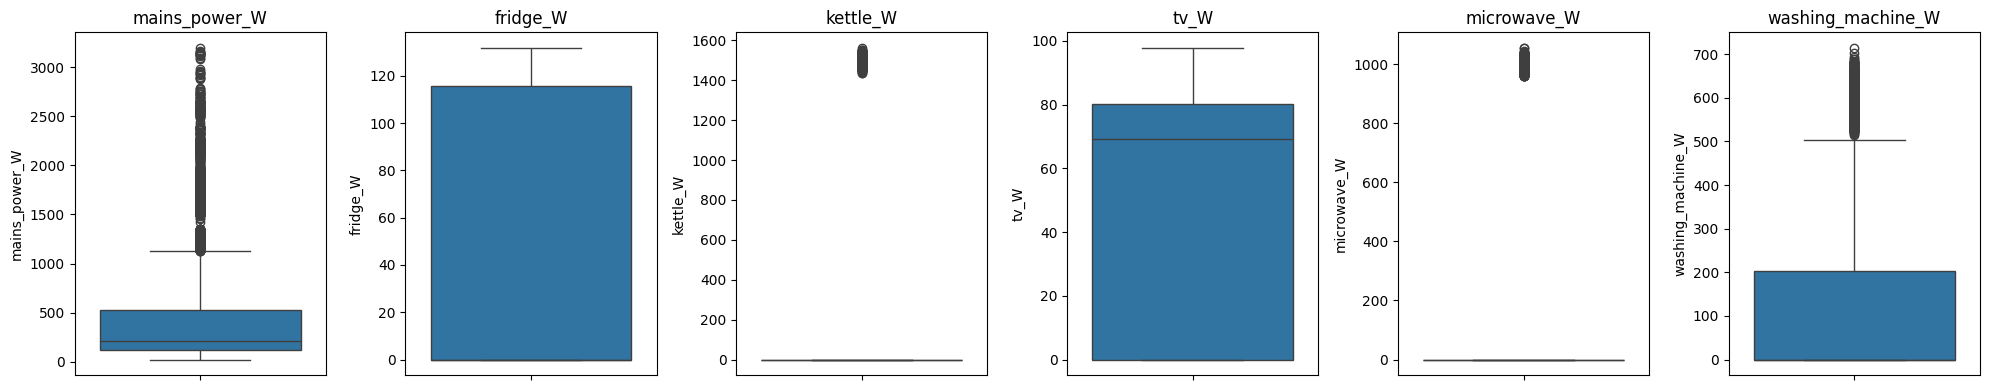

In [58]:
# Finding the outliers

fig,axs = plt.subplots(nrows=1,ncols = 6,figsize = (20,4))
axs = axs.flatten()
index = 0

for col,value in data.items():
    axs[index].set_title(f"{col}")
    sns.boxplot(y= col,ax = axs[index],data = data)
    index += 1

plt.tight_layout()


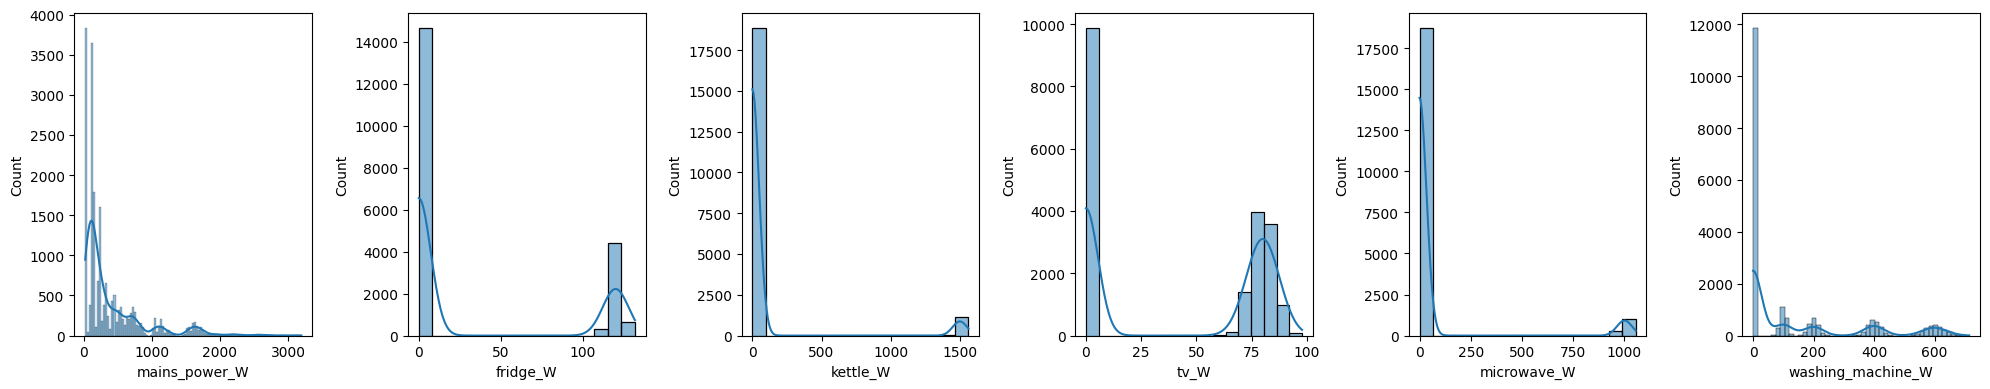

In [59]:
# Studying the distribution

fig,axs = plt.subplots(ncols=6,nrows = 1,figsize = (20,4))
axs = axs.flatten()
index = 0

for col,value in data.items():
    sns.histplot(value,ax = axs[index],kde = True)
    index += 1

plt.tight_layout()

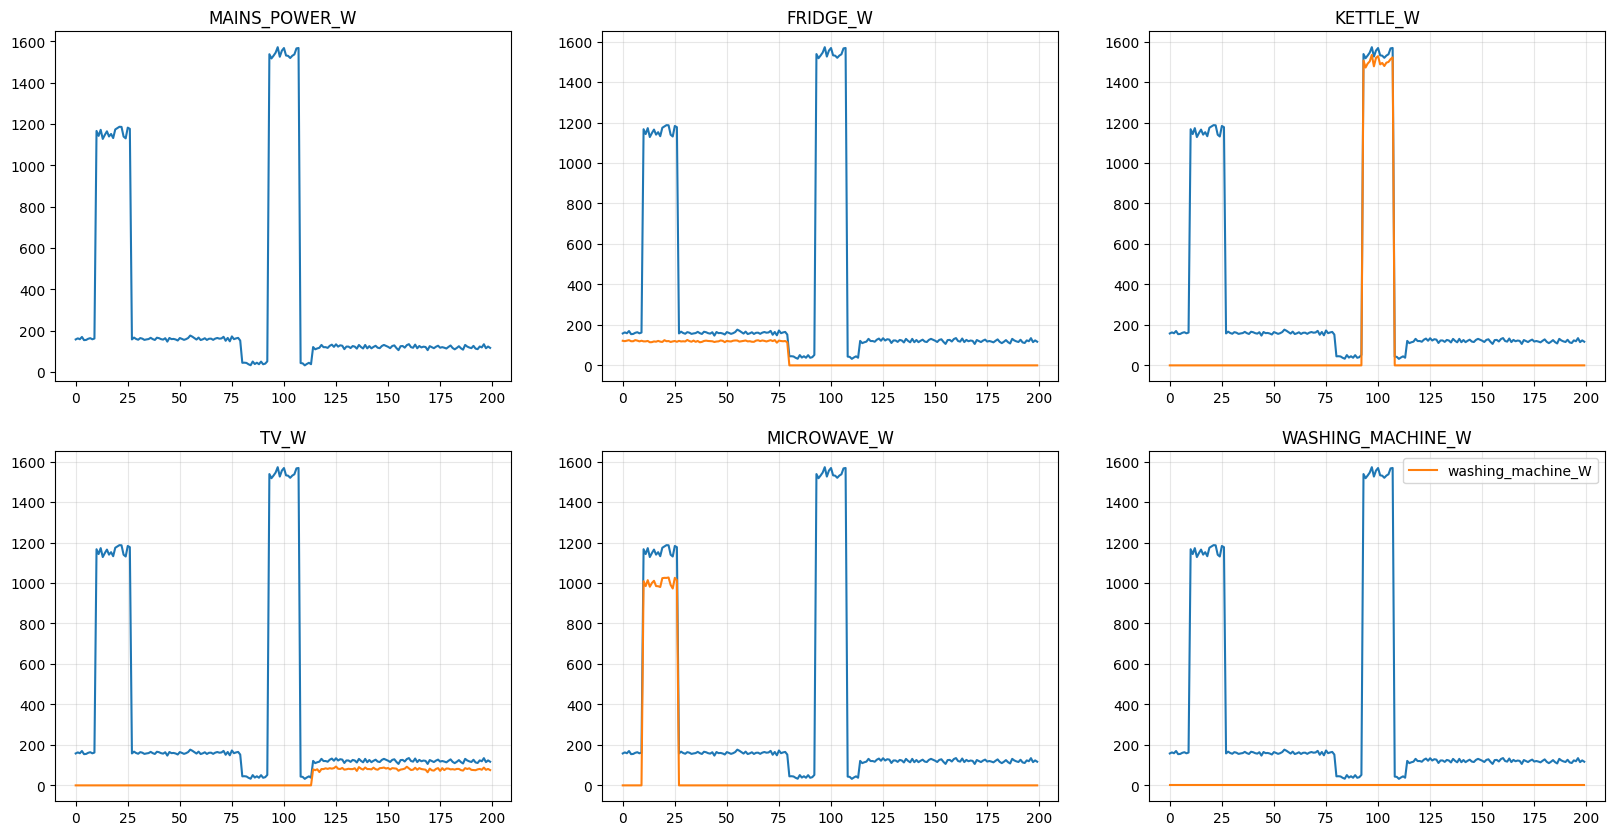

In [60]:
# Visualization of main power vs appliances
# Our data is very large, for visualization seeing upto 200

fig,axs = plt.subplots(ncols = 3,nrows = 2,figsize = (20,10))
axs = axs.flatten()
index = 1

axs[0].set_title("MAINS_POWER_W")
axs[0].plot(data["mains_power_W"].head(200))

for col,value in data.items():
    if col != "mains_power_W":
        axs[index].set_title(f"{col.upper()}")
        axs[index].plot(data["mains_power_W"].head(200))
        axs[index].plot(data[col].head(200),label=f"{col}")
        axs[index].grid(True,alpha = 0.3)
        index += 1

plt.legend()

In [61]:
# Conversion of Regression into Classification

'''
Converting Regression problem into classification problem. 

For each appliance we have given the power values, lets classify these values into appliance
ON state or OFF state,if the power consumption is greater than 10 W then lets make it ON, 
doing this for all the appliances

'''

for col in data.columns:
    if col!="mains_power_W":
        data[col] = (data[col] > 10).astype(int)

data.head()


,mains_power_W,fridge_W,kettle_W,tv_W,microwave_W,washing_machine_W
0,157.72,1,0,0,0,0
1,162.94,1,0,0,0,0
2,158.73,1,0,0,0,0
3,169.84,1,0,0,0,0
4,154.31,1,0,0,0,0


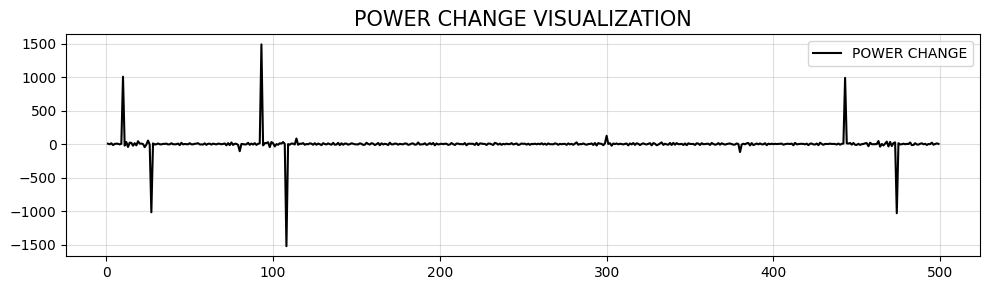

In [62]:
# Power Change detection

data["power_change"] = data["mains_power_W"].diff()
plt.figure(figsize=(10,3))
plt.title("POWER CHANGE VISUALIZATION",fontsize = 15)

# Our data is very large, for visualization seeing upto 200

plt.plot(data["power_change"].head(500),color = "k",label = "POWER CHANGE") 
plt.tight_layout()
plt.grid(True,alpha = 0.4)
plt.legend()
plt.show()

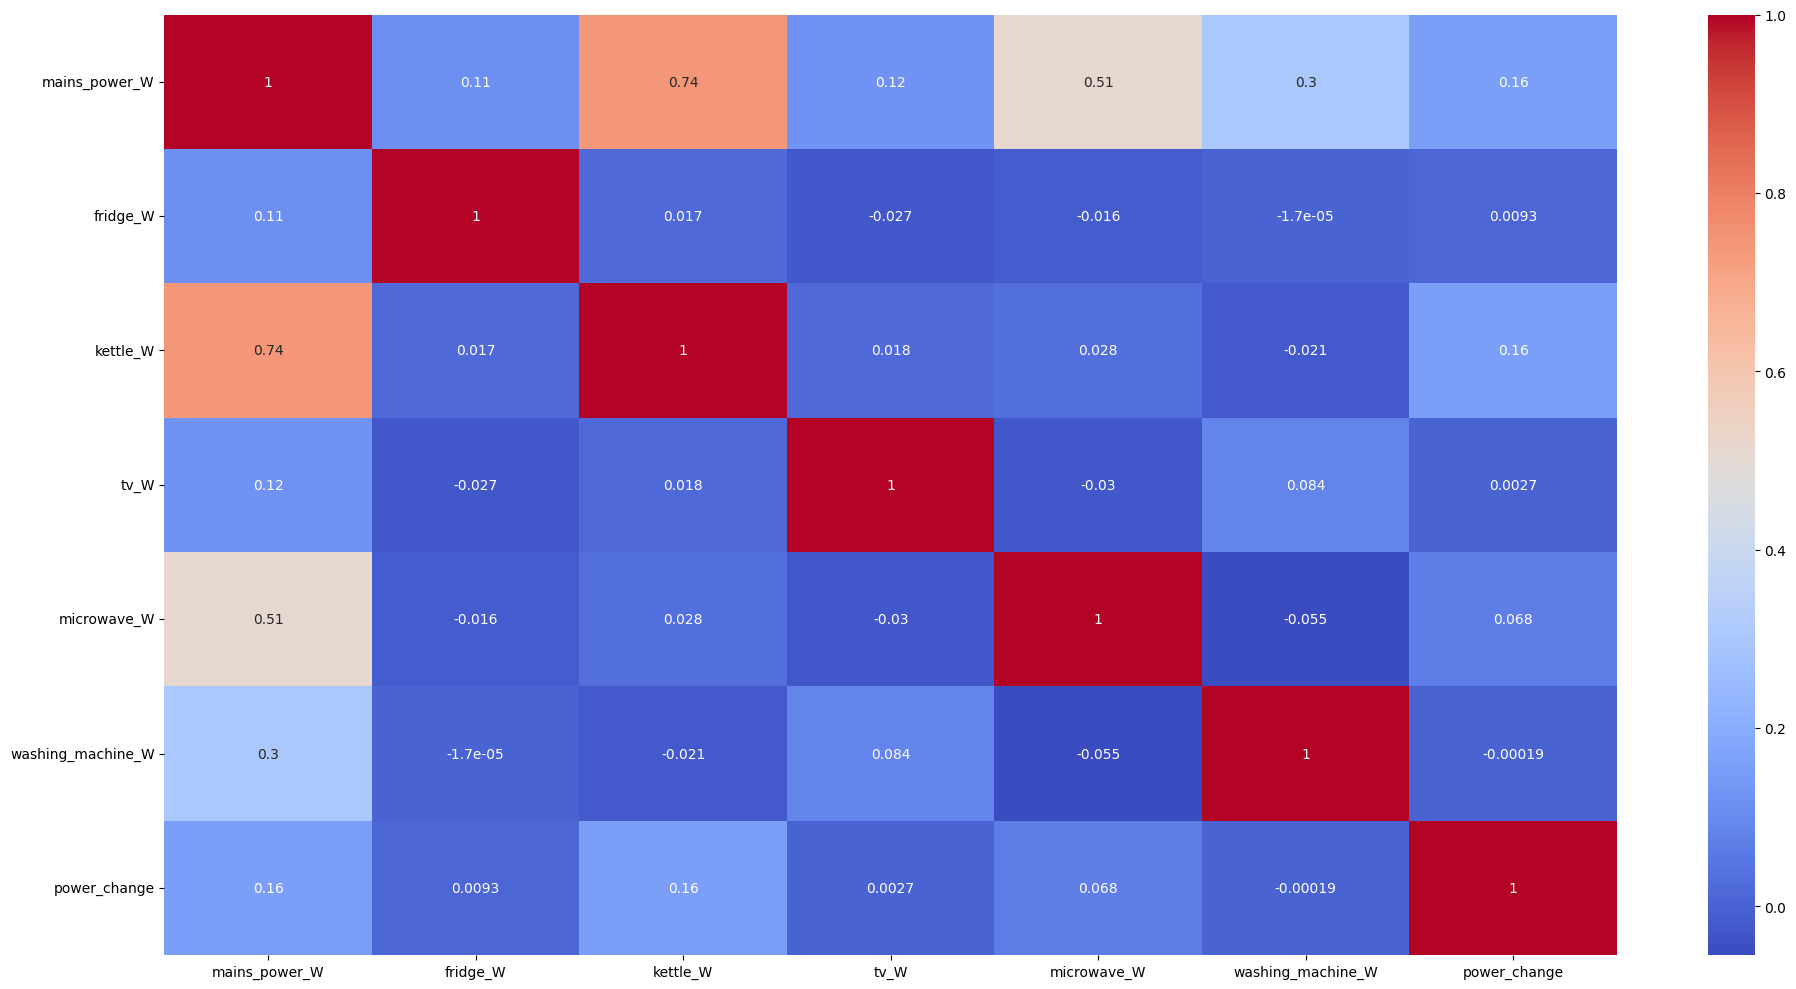

In [63]:
# Checking the Relationships :

corr = data.corr()
fig,axs = plt.subplots(figsize = (20,10))
sns.heatmap(corr,ax = axs,cmap = "coolwarm",annot = True)
plt.tight_layout()
plt.show()

In [64]:
# For concept lets do only for Kettle_W for now
# Understanding the nature between power change and Kettle_W

display(data[["power_change","kettle_W"]])

,power_change,kettle_W
0,NaN,0
1,5.22,0
2,-4.21,0
3,11.11,0
4,-15.53,0
...,...,...
19995,7.89,0
19996,3.94,0
19997,-6.86,0
19998,5.45,0


In [65]:
# MODEL MAKING FOR KETTLE
# Chosing dependent and independent variables
x_ = data[["mains_power_W","power_change"]]
y = data["kettle_W"]

In [66]:
# Making the function

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

def train(model,x,y):
    x_train,x_test, y_train,y_test = train_test_split(x,y,random_state=42)
    model.fit(x_train,y_train)
    prediction = model.predict(x_test)
    cv_score = cross_val_score(model,x,y,scoring="neg_mean_squared_error",cv=  5)
    cv_score = np.abs(np.mean(cv_score))

    print("MODEL REPORT")
    print("MSE : ",mean_squared_error(y_test,prediction))
    print("CV SCORE : ",cv_score)

MODEL REPORT
MSE :  0.0138
CV SCORE :  0.015749999999999997


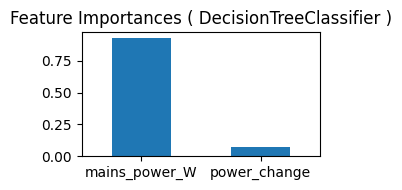

In [67]:
# Using the model : DecisionTreeClassifier

from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

model = DecisionTreeClassifier()
train(model, x_, y)
coeff = pd.Series(model.feature_importances_, x_.columns).sort_values(ascending=False)

fig, axs = plt.subplots(figsize=(3, 2)) 
coeff.plot(kind="bar", title="Feature Importances ( DecisionTreeClassifier )", ax=axs)
plt.xticks(rotation=0) 
plt.tight_layout()
plt.show()

MODEL REPORT
MSE :  0.0102
CV SCORE :  0.012499999999999999


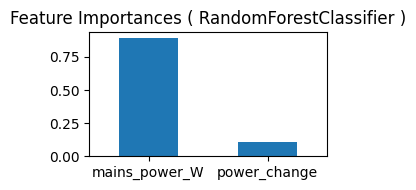

In [68]:
# Using model : RandomForestClassifier

from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
train(model,x_,y)
coeff = pd.Series(model.feature_importances_,x_.columns).sort_values(ascending=False)

fig, axs = plt.subplots(figsize=(3, 2)) 
coeff.plot(kind="bar", title="Feature Importances ( RandomForestClassifier )", ax=axs)
plt.xticks(rotation=0) 
plt.tight_layout()
plt.show()

MODEL REPORT
MSE :  0.008
CV SCORE :  0.01245


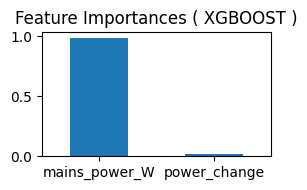

In [69]:
# For minimum possible error using XGBOOST
# Using model : XBGClassifier

from xgboost import XGBClassifier
model = XGBClassifier(n_estimators = 100, 
            learning_rate = 0.1, max_depth = 5,
            random_state = 42)
train(model,x_,y)
coeff = pd.Series(model.feature_importances_,x_.columns).sort_values(ascending=False)

fig, axs = plt.subplots(figsize=(3, 2)) 
coeff.plot(kind="bar", title="Feature Importances ( XGBOOST )", ax=axs)
plt.xticks(rotation=0) 
plt.tight_layout()
plt.show()


MODEL REPORT
MSE :  0.008
CV SCORE :  0.01245


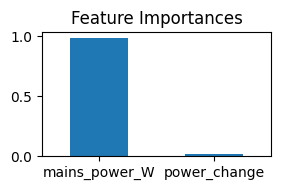

In [70]:
# Now Performing the Model Training for various appliances

# Appliance Type : Kettle
from xgboost import XGBClassifier
model = XGBClassifier(n_estimators = 100, 
            learning_rate = 0.1, max_depth = 5,
            random_state = 42)
train(model,x_,y)
coeff = pd.Series(model.feature_importances_,x_.columns).sort_values(ascending=False)

fig, axs = plt.subplots(figsize=(3, 2)) 
coeff.plot(kind="bar", title="Feature Importances", ax=axs)
plt.xticks(rotation=0) 
plt.tight_layout()
plt.show()

MODEL REPORT
MSE :  0.0916
CV SCORE :  0.1031


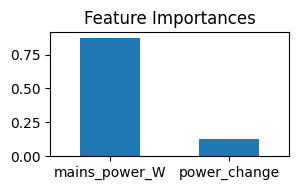

In [71]:
# Appliance Type = Fridge
y = data["fridge_W"]
from xgboost import XGBClassifier
model = XGBClassifier(n_estimators = 100, 
            learning_rate = 0.1, max_depth = 5,
            random_state = 42)
train(model,x_,y)
coeff = pd.Series(model.feature_importances_,x_.columns).sort_values(ascending=False)

fig, axs = plt.subplots(figsize=(3, 2)) 
coeff.plot(kind="bar", title="Feature Importances", ax=axs)
plt.xticks(rotation=0) 
plt.tight_layout()
plt.show()


MODEL REPORT
MSE :  0.0886
CV SCORE :  0.1036


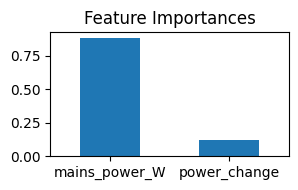

In [72]:
# Appliance Type = TV
y = data["tv_W"]
from xgboost import XGBClassifier
model = XGBClassifier(n_estimators = 100, 
            learning_rate = 0.1, max_depth = 5,
            random_state = 42)
train(model,x_,y)
coeff = pd.Series(model.feature_importances_,x_.columns).sort_values(ascending=False)

fig, axs = plt.subplots(figsize=(3, 2)) 
coeff.plot(kind="bar", title="Feature Importances", ax=axs)
plt.xticks(rotation=0) 
plt.tight_layout()
plt.show()

MODEL REPORT
MSE :  0.0104
CV SCORE :  0.01315


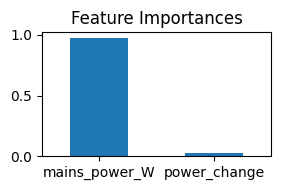

In [73]:
# Appliance Type = Microwave
y = data["microwave_W"]
from xgboost import XGBClassifier
model = XGBClassifier(n_estimators = 100, 
            learning_rate = 0.1, max_depth = 5,
            random_state = 42)
train(model,x_,y)
coeff = pd.Series(model.feature_importances_,x_.columns).sort_values(ascending=False)

fig, axs = plt.subplots(figsize=(3, 2)) 
coeff.plot(kind="bar", title="Feature Importances", ax=axs)
plt.xticks(rotation=0) 
plt.tight_layout()
plt.show()

MODEL REPORT
MSE :  0.0552
CV SCORE :  0.0596


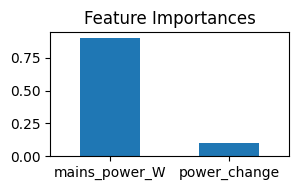

In [74]:
# Appliance Type = Washing Machine
y = data["washing_machine_W"]
from xgboost import XGBClassifier
model = XGBClassifier(n_estimators = 100, 
            learning_rate = 0.1, max_depth = 5,
            random_state = 42)
train(model,x_,y)
coeff = pd.Series(model.feature_importances_,x_.columns).sort_values(ascending=False)

fig, axs = plt.subplots(figsize=(3, 2)) 
coeff.plot(kind="bar", title="Feature Importances", ax=axs)
plt.xticks(rotation=0) 
plt.tight_layout()
plt.show()

# ----------------------------------------
### MAKING THE SYSTEM FOR INTELLEGENT THAN BEFORE ...
~ As you can see that in this model, our data is being trained on real time values,
that is the model sees energy spike of certain appliances and then it guesses which
appliance is it. 
But in actual practice this is not very ideal, as energy consumption must also be seen
as compared to the previous energy level value, so to do this we are going to introduce
some more feature columns and then it will make our model more intelligent

Rolling Mean : {  IDENTIFYING THE TYPE } <br>
Basically it is the average of powers of previous reading, for this model training I am
taking the average of 5 power readings. Here if the current reading is 2000W and the 
rolling mean is 500W then model knows that something has been turned on. Like wise if
the current reading is 2000W and then rolling mean is also 2000W then the model will
know that appliance has been on for previous time also.

In [75]:
data["rolling_mean"] = data["mains_power_W"].rolling(5).mean()
data["rolling_mean"].tail()

19995    37.510
19996    38.110
19997    36.646
19998    37.062
19999    39.324
Name: rolling_mean, dtype: float64

Rolling Standard Deviation : { IDENTIFIES THE TEXTURE }
It is used to measure the stability or changing of the previous reading, for this model training I am taking the standard deviation of previous 5 values. This helps to know the 
nature of change of the electricity as different appliances have different type of energy
drawing nature with them. Example :  Fridge takes stable power while washing machine shows fluctuation type of energy consumption.


In [76]:
data["rolling_std"] = data["mains_power_W"].rolling(5).std()
data["rolling_std"].tail()

19995    4.522615
19996    4.928899
19997    4.423271
19998    4.715291
19999    2.847416
Name: rolling_std, dtype: float64

In [77]:
data["prev_power"] = data["mains_power_W"].shift(1)
display(data["prev_power"].head())

0       NaN
1    157.72
2    162.94
3    158.73
4    169.84
Name: prev_power, dtype: float64

In [78]:
data["abs_change"] = abs(data["power_change"])
display(data["abs_change"].head())

0      NaN
1     5.22
2     4.21
3    11.11
4    15.53
Name: abs_change, dtype: float64

In [79]:
# Making the new function that returns the model for saving purpose

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

def train_model(model,x,y):
    x_train,x_test, y_train,y_test = train_test_split(x,y,random_state=42)
    model_name = model.fit(x_train,y_train)
    prediction = model.predict(x_test)
    cv_score = cross_val_score(model,x,y,scoring="neg_mean_squared_error",cv=  5)
    cv_score = np.abs(np.mean(cv_score))

    print("MODEL REPORT")
    print("MSE : ",mean_squared_error(y_test,prediction))
    print("CV SCORE : ",cv_score)

    return model_name

MODEL REPORT
MSE :  0.0078
CV SCORE :  0.011750000000000002


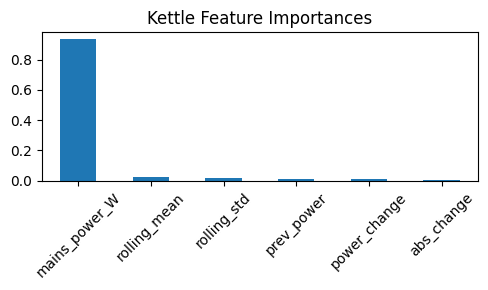

In [80]:
# Retraining the Model using new features added

x = data[["mains_power_W","power_change",
          "rolling_mean","rolling_std",
          "prev_power","abs_change"]]

# Appliance Type : Kettle 
y = data["kettle_W"]
model = XGBClassifier(n_estimators = 100, 
            learning_rate = 0.1, max_depth = 5,
            random_state = 42)

kettle_model = train_model(model,x,y)
coeff = pd.Series(model.feature_importances_,x.columns).sort_values(ascending=False)

fig, axs = plt.subplots(figsize=(5, 3)) 
coeff.plot(kind="bar", title="Kettle Feature Importances", ax=axs)
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()


MODEL REPORT
MSE :  0.0584
CV SCORE :  0.07285


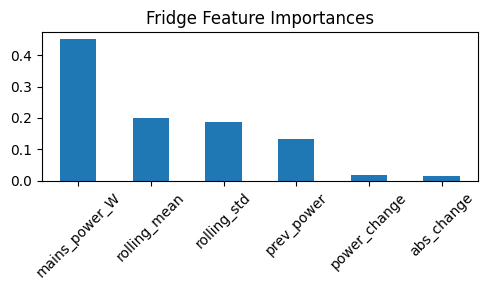

In [81]:
# Appliance Type : Fridge

y = data["fridge_W"]
model = XGBClassifier(n_estimators = 100, 
            learning_rate = 0.1, max_depth = 5,
            random_state = 42)
fridge_model = train_model(model,x,y)
coeff = pd.Series(model.feature_importances_,x.columns).sort_values(ascending=False)

fig, axs = plt.subplots(figsize=(5, 3)) 
coeff.plot(kind="bar", title="Fridge Feature Importances", ax=axs)
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()


MODEL REPORT
MSE :  0.0528
CV SCORE :  0.0706


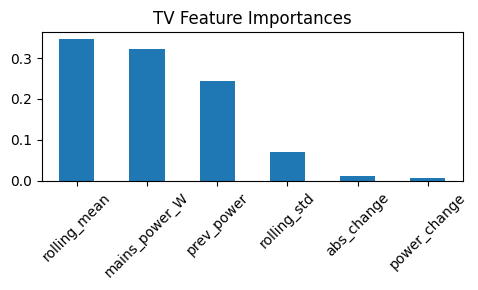

In [82]:
# Appliance Type : TV

y = data["tv_W"]
model = XGBClassifier(n_estimators = 100, 
            learning_rate = 0.1, max_depth = 5,
            random_state = 42)
tv_model = train_model(model,x,y)
coeff = pd.Series(model.feature_importances_,x.columns).sort_values(ascending=False)

fig, axs = plt.subplots(figsize=(5, 3)) 
coeff.plot(kind="bar", title="TV Feature Importances", ax=axs)
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()


MODEL REPORT
MSE :  0.0084
CV SCORE :  0.01145


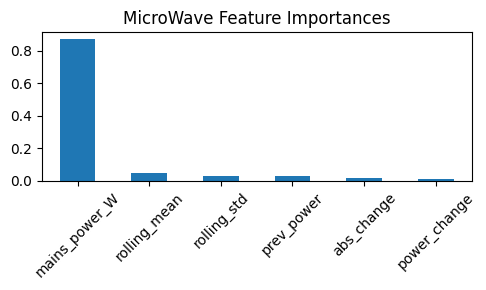

In [83]:
# Appliance Type : Microwave

y = data["microwave_W"]
model = XGBClassifier(n_estimators = 100, 
            learning_rate = 0.1, max_depth = 5,
            random_state = 42)

microwave_model = train_model(model,x,y)

coeff = pd.Series(model.feature_importances_,x.columns).sort_values(ascending=False)

fig, axs = plt.subplots(figsize=(5, 3)) 
coeff.plot(kind="bar", title="MicroWave Feature Importances", ax=axs)
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()


MODEL REPORT
MSE :  0.0274
CV SCORE :  0.0355


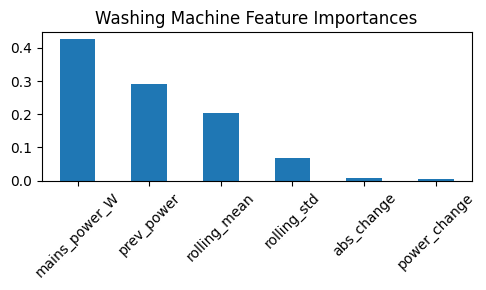

In [84]:
# Appliance Type : Washing Machine

y = data["washing_machine_W"]
model = XGBClassifier(n_estimators = 100, 
            learning_rate = 0.1, max_depth = 5,
            random_state = 42)
washing_machine_model = train_model(model,x,y)
coeff = pd.Series(model.feature_importances_,x.columns).sort_values(ascending=False)

fig, axs = plt.subplots(figsize=(5, 3)) 
coeff.plot(kind="bar", title="Washing Machine Feature Importances", ax=axs)
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()

In [85]:
# TIME STAMP PREDICTION

status_data = data.drop(columns=["mains_power_W",
                                 "rolling_mean","rolling_std",
                                 "prev_power","abs_change",
                                 "power_change"])


status_data = status_data.replace({0:"OFF",1:"ON"})

status_data = pd.concat([time_data,status_data],axis = 1)
status_data.columns = ["TIME STAMP","FRIDGE",
                       "KETTLE",
                       "TV","MICROWAVE",
                       "WASHING MACHINE"]

status_data.head()

,TIME STAMP,FRIDGE,KETTLE,TV,MICROWAVE,WASHING MACHINE
0,2026-01-01 00:00:00,ON,OFF,OFF,OFF,OFF
1,2026-01-01 00:00:06,ON,OFF,OFF,OFF,OFF
2,2026-01-01 00:00:12,ON,OFF,OFF,OFF,OFF
3,2026-01-01 00:00:18,ON,OFF,OFF,OFF,OFF
4,2026-01-01 00:00:24,ON,OFF,OFF,OFF,OFF


In [86]:
appliance_data = data.drop(columns=["mains_power_W",
                                 "rolling_mean","rolling_std",
                                 "prev_power","abs_change",
                                 "power_change"])

In [87]:
# import joblib

# joblib.dump(fridge_model,"fridge_model.pkl")
# joblib.dump(kettle_model,"kettle_model.pkl")
# joblib.dump(tv_model,"tv_model.pkl")
# joblib.dump(microwave_model,"microwave_model.pkl")
# joblib.dump(washing_machine_model,"washing_machine_model.pkl")

# ------------------------------------------------
### Making Further enhancement in intellegence ...

Adding electrical signature features :<br>
Currently our model is operating based on active power (W) and its related engineered features like rolling mean, absolute change etc... Now to add depth in the knowledge of our model we have to know the rms current and voltage values. For a daily practical system, the rms voltage usually remains constant about 220 V but the behaviour of current changes.<br><br>
Every appliance has different current signatures and we can use this variation of current signature to feed knowledge to our model and predict which type of appliance it is currently being operated. 

In [88]:
# Loading the Electrical Data

electrical_data = pd.read_csv("Current_Voltage_Data.csv")
current_data = electrical_data["current_A"]
voltage_data = electrical_data["voltage_V"]

~ Since we have now the values of current, voltage and active power at each instant of time for the mains supply, using the standard relationship we can now find the value of power factor of mains at each instant of time. Power factor variation occurs with time can be taken as a very important electrical signature which can be used to train our model and can act as additional features to our model to make it more intelligent.

In [89]:
# Finding power factor
pf_data = data["mains_power_W"] / (current_data * voltage_data )
pf_data = pd.DataFrame(pf_data,columns=["pf"])
display(pf_data.head())

,pf
0,0.831971
1,0.843373
2,0.800315
3,0.782983
4,0.757169


In [90]:
# Remaking the Reference DataFrame

data["current_A"] = current_data
data["voltage_V"] = voltage_data
data["pf"] = pf_data
data.head()

,mains_power_W,fridge_W,kettle_W,tv_W,microwave_W,washing_machine_W,power_change,rolling_mean,rolling_std,prev_power,abs_change,current_A,voltage_V,pf
0,157.72,1,0,0,0,0,NaN,NaN,NaN,NaN,NaN,0.824234,230.0,0.831971
1,162.94,1,0,0,0,0,5.22,NaN,NaN,157.72,5.22,0.840002,230.0,0.843373
2,158.73,1,0,0,0,0,-4.21,NaN,NaN,162.94,4.21,0.862324,230.0,0.800315
3,169.84,1,0,0,0,0,11.11,NaN,NaN,158.73,11.11,0.943105,230.0,0.782983
4,154.31,1,0,0,0,0,-15.53,160.708,5.96134,169.84,15.53,0.886081,230.0,0.757169


In [91]:
# Retraining the Model using new features added

# Note : RMS Voltage is constant so doesnt participate in learning the model
x = data[["mains_power_W","power_change",
          "rolling_mean","rolling_std",
          "prev_power","abs_change",
          "current_A","pf"]]

In [92]:
# Making the new function that returns the model for saving purpose

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

def train_model_adv(model,x,y):
    x_train,x_test, y_train,y_test = train_test_split(x,y,random_state=42)
    model_name = model.fit(x_train,y_train)
    prediction = model.predict(x_test)
    cv_score = cross_val_score(model,x,y,scoring="neg_mean_squared_error",cv=  5)
    cv_score = np.abs(np.mean(cv_score))

    print("MODEL REPORT")
    print("MSE : ",mean_squared_error(y_test,prediction))
    print("CV SCORE : ",cv_score)

    return model_name

MODEL REPORT
MSE :  0.057
CV SCORE :  0.07315


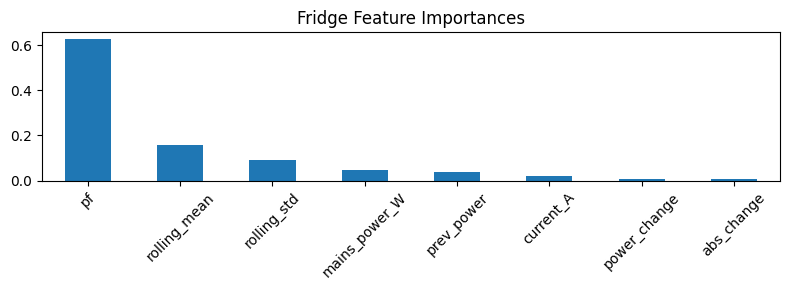

In [93]:
# Appliance Type : Fridge

y = data["fridge_W"]
model = XGBClassifier(n_estimators = 100, 
            learning_rate = 0.1, max_depth = 5,
            random_state = 42)
fridge_model_adv = train_model_adv(model,x,y)
coeff = pd.Series(model.feature_importances_,x.columns).sort_values(ascending=False)

fig, axs = plt.subplots(figsize=(8, 3)) 
coeff.plot(kind="bar", title="Fridge Feature Importances", ax=axs)
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()


MODEL REPORT
MSE :  0.0064
CV SCORE :  0.0092


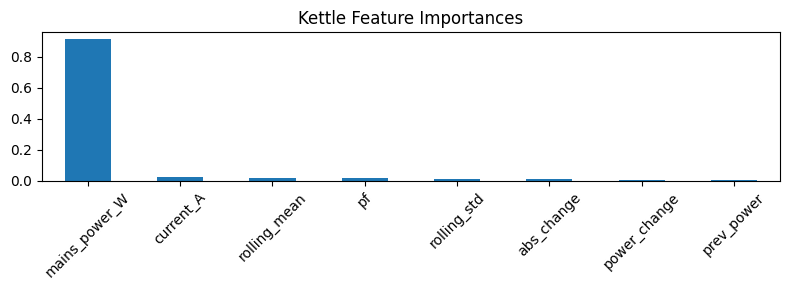

In [94]:
# Appliance Type : Kettle 

y = data["kettle_W"]
model = XGBClassifier(n_estimators = 100, 
            learning_rate = 0.1, max_depth = 5,
            random_state = 42)

kettle_model_adv = train_model_adv(model,x,y)
coeff = pd.Series(model.feature_importances_,x.columns).sort_values(ascending=False)

fig, axs = plt.subplots(figsize=(8, 3)) 
coeff.plot(kind="bar", title="Kettle Feature Importances", ax=axs)
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()

MODEL REPORT
MSE :  0.0482
CV SCORE :  0.06065


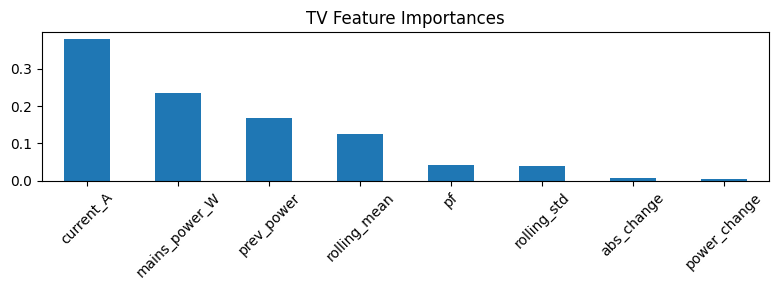

In [95]:
# Appliance Type : TV

y = data["tv_W"]
model = XGBClassifier(n_estimators = 100, 
            learning_rate = 0.1, max_depth = 5,
            random_state = 42)
tv_model_adv = train_model_adv(model,x,y)
coeff = pd.Series(model.feature_importances_,x.columns).sort_values(ascending=False)

fig, axs = plt.subplots(figsize=(8, 3)) 
coeff.plot(kind="bar", title="TV Feature Importances", ax=axs)
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()

MODEL REPORT
MSE :  0.0064
CV SCORE :  0.008949999999999998


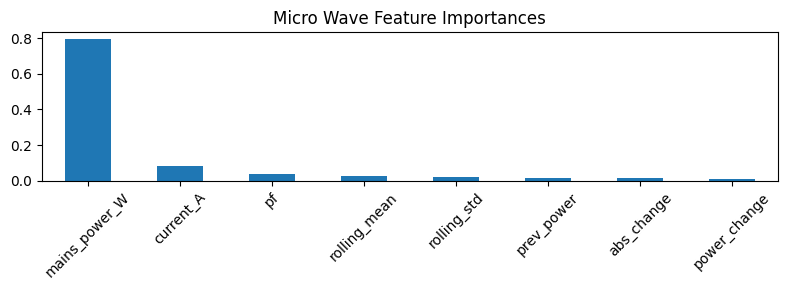

In [96]:
# Appliance Type : Micro Wave

y = data["microwave_W"]
model = XGBClassifier(n_estimators = 100, 
            learning_rate = 0.1, max_depth = 5,
            random_state = 42)
microwave_model_adv = train_model_adv(model,x,y)
coeff = pd.Series(model.feature_importances_,x.columns).sort_values(ascending=False)

fig, axs = plt.subplots(figsize=(8, 3)) 
coeff.plot(kind="bar", title="Micro Wave Feature Importances", ax=axs)
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()

MODEL REPORT
MSE :  0.0198
CV SCORE :  0.0269


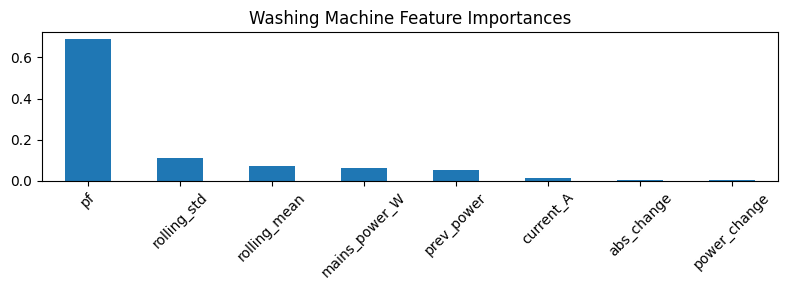

In [97]:
# Appliance Type : Washing Machine

y = data["washing_machine_W"]
model = XGBClassifier(n_estimators = 100, 
            learning_rate = 0.1, max_depth = 5,
            random_state = 42)
washing_machine_model_adv = train_model_adv(model,x,y)
coeff = pd.Series(model.feature_importances_,x.columns).sort_values(ascending=False)

fig, axs = plt.subplots(figsize=(8, 3)) 
coeff.plot(kind="bar", title="Washing Machine Feature Importances", ax=axs)
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()

In [98]:
# Saving the models

import joblib

joblib.dump(fridge_model_adv,"models/fridge_model.pkl")
joblib.dump(kettle_model_adv,"models/kettle_model.pkl")
joblib.dump(tv_model_adv,"models/tv_model.pkl")
joblib.dump(microwave_model_adv,"models/microwave_model.pkl")
joblib.dump(washing_machine_model_adv,"models/washing_machine_model.pkl")

['models/washing_machine_model.pkl']